In [7]:
suppressPackageStartupMessages(library(SingleCellExperiment))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(argparse))
#####################
## Define settings ##
#####################
here::i_am("processing/1_create_seurat_rna.R")
source(here::here("settings.R"))
source(here::here("utils.R"))



here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/code



In [8]:
args = list()
args$samples <- opts$samples
args$sce <- io$rna.sce
args$metadata <- "/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/results/rna/mapping/sample_metadata_after_mapping.txt.gz"
# args$metadata <- paste0(io$basedir,"/results/rna/doublets/sample_metadata_after_doublets.txt.gz")
args$features <- 3000
args$npcs <- 40
args$n_neighbors = 30
args$min_dist = 0.3
args$test <- FALSE
args$colour_by <- c("celltype.mapped_mnn","sample")
args$vars.to.regress <- c("nFeature_RNA","mitochondrial_percent_RNA")
args$batch_correction <- c("stage")
args$remove_ExE_cells <- FALSE
args$outdir <- paste0(io$basedir,"/results/rna/dimensionality_reduction/test")

In [9]:
dir.create(args$outdir, recursive=TRUE, showWarnings = FALSE)

In [10]:
sample_metadata <- fread(args$metadata) %>%
   .[pass_rnaQC==TRUE & doublet_call==FALSE & sample%in%args$samples]

if (args$remove_ExE_cells) {
  print("Removing ExE cells...")
  sample_metadata <- sample_metadata %>%
    .[!celltype.mapped_mnn%in%c("Visceral_endoderm","ExE_endoderm","ExE_ectoderm","Parietal_endoderm")]
}

In [11]:
head(sample_metadata, 2)

cell,sample,barcode,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,stage,tdTom,idx,tdTom_corr,pass_rnaQC,doublet_score,doublet_call,celltype.mapped_mnn,celltype.score_mnn,stage.mapped_mnn,cellstage.score_mnn,closest.cell_mnn
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<lgl>,<int>,<lgl>,<lgl>,<dbl>,<lgl>,<chr>,<dbl>,<chr>,<dbl>,<chr>
SLX-21143_SITTA2_HTJH3DSX2#AAACCCAAGATGTTCC-1,SLX-21143_SITTA2_HTJH3DSX2,AAACCCAAGATGTTCC-1,4837,53199,1.47,22.87,E8.5,TRUE,1,TRUE,TRUE,0.09,FALSE,Erythroid,1,E8.0,0.56,cell_33109
SLX-21143_SITTA2_HTJH3DSX2#AAACCCATCAGACCTA-1,SLX-21143_SITTA2_HTJH3DSX2,AAACCCATCAGACCTA-1,4973,24165,0.95,19.26,E8.5,TRUE,3,TRUE,TRUE,0.24,FALSE,Mesenchyme,1,E8.75,0.44,ext_cell_141053


In [12]:
###################
## Sanity checks ##
###################

stopifnot(args$colour_by %in% colnames(sample_metadata))
# stopifnot(unique(sample_metadata$celltype.mapped) %in% names(opts$celltype.colors))

 if (length(args$batch_correction)>0) {
   stopifnot(args$batch_correction%in%colnames(sample_metadata))
   if (length(unique(sample_metadata[[args$batch_correction]]))==1) {
     message(sprintf("There is a single level for %s, no batch correction applied",args$batch_correction))
     args$batch_correction <- NULL
   } else {
     library(batchelor)
   }
 }

 if (length(args$vars_to_regress)>0) {
  stopifnot(args$vars_to_regress%in%colnames(sample_metadata))
 }

In [13]:

###############
## Load data ##
###############

# Load RNA expression data as SingleCellExperiment object
sce <- load_SingleCellExperiment(args$sce, cells=sample_metadata$cell, normalise = TRUE)

# Add sample metadata as colData
colData(sce) <- sample_metadata %>% tibble::column_to_rownames("cell") %>% DataFrame


In [14]:
sce

class: SingleCellExperiment 
dim: 29453 44673 
metadata(0):
assays(2): counts logcounts
rownames(29453): Xkr4 Gm1992 ... CAAA01147332.1 tomato-td
rowData names(0):
colnames(44673): SLX-21143_SITTA2_HTJH3DSX2#AAACCCAAGATGTTCC-1
  SLX-21143_SITTA2_HTJH3DSX2#AAACCCATCAGACCTA-1 ...
  SLX-21143_SITTH3_HTJH3DSX2#TTTGTTGGTAAGATCA-1
  SLX-21143_SITTH3_HTJH3DSX2#TTTGTTGGTCATCGGC-1
colData names(18): sample barcode ... cellstage.score_mnn
  closest.cell_mnn
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

# No batch correction

In [16]:
decomp <- modelGeneVar(sce)
decomp <- decomp[decomp$mean > 0.01,]
hvgs <- decomp[order(decomp$FDR),] %>% head(n=args$features) %>% rownames # Filter out certain genes like ribosomal/mito/pseudo before selecting top features

# Subset SingleCellExperiment
sce_filt <- sce[hvgs,]

In [26]:
head(hvgs, 50)

[1] "Hbb-bh1"   "Hbb-y"     "Hba-x"     "Hba-a1"    "Gm42418"   "mt-Co2"   
 [7] "mt-Co3"    "Crabp1"    "mt-Atp6"   "Tmsb4x"    "Hist1h1b"  "mt-Cytb"  
[13] "mt-Nd1"    "mt-Co1"    "H19"       "Peg3"      "Hist1h2ap" "Mest"     
[19] "Ptn"       "Vim"       "mt-Nd2"    "Phlda2"    "Xist"      "mt-Nd4"   
[25] "Malat1"    "Meg3"      "Crabp2"    "Lyve1"     "Hbb-bs"    "Ttr"      
[31] "Gypa"      "Cited4"    "Krt8"      "Ccnd2"     "Tuba1a"    "Krt18"    
[37] "Nepn"      "Cdkn1c"    "Ckb"       "Ankrd1"    "Id3"       "Slc4a1"   
[43] "Alas2"     "Spink1"    "Acta2"     "Epcam"     "Nppa"      "Csrp3"    
[49] "Apom"      "Igf2"

In [12]:
sce_filt <- runPCA(sce_filt, ncomponents = args$npcs, ntop=args$features)  

In [13]:
sce_filt <- runUMAP(sce_filt, dimred="PCA", n_neighbors = args$n_neighbors, min_dist = args$min_dist)

# Fetch UMAP coordinates
umap.dt <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
  .[,cell:=colnames(sce_filt)] %>%
  setnames(c("UMAP1","UMAP2","cell"))

In [47]:
io$gene_metadata

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Mmusculus_genes_BioMart.87.txt"

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation ideoms with `aes()`”


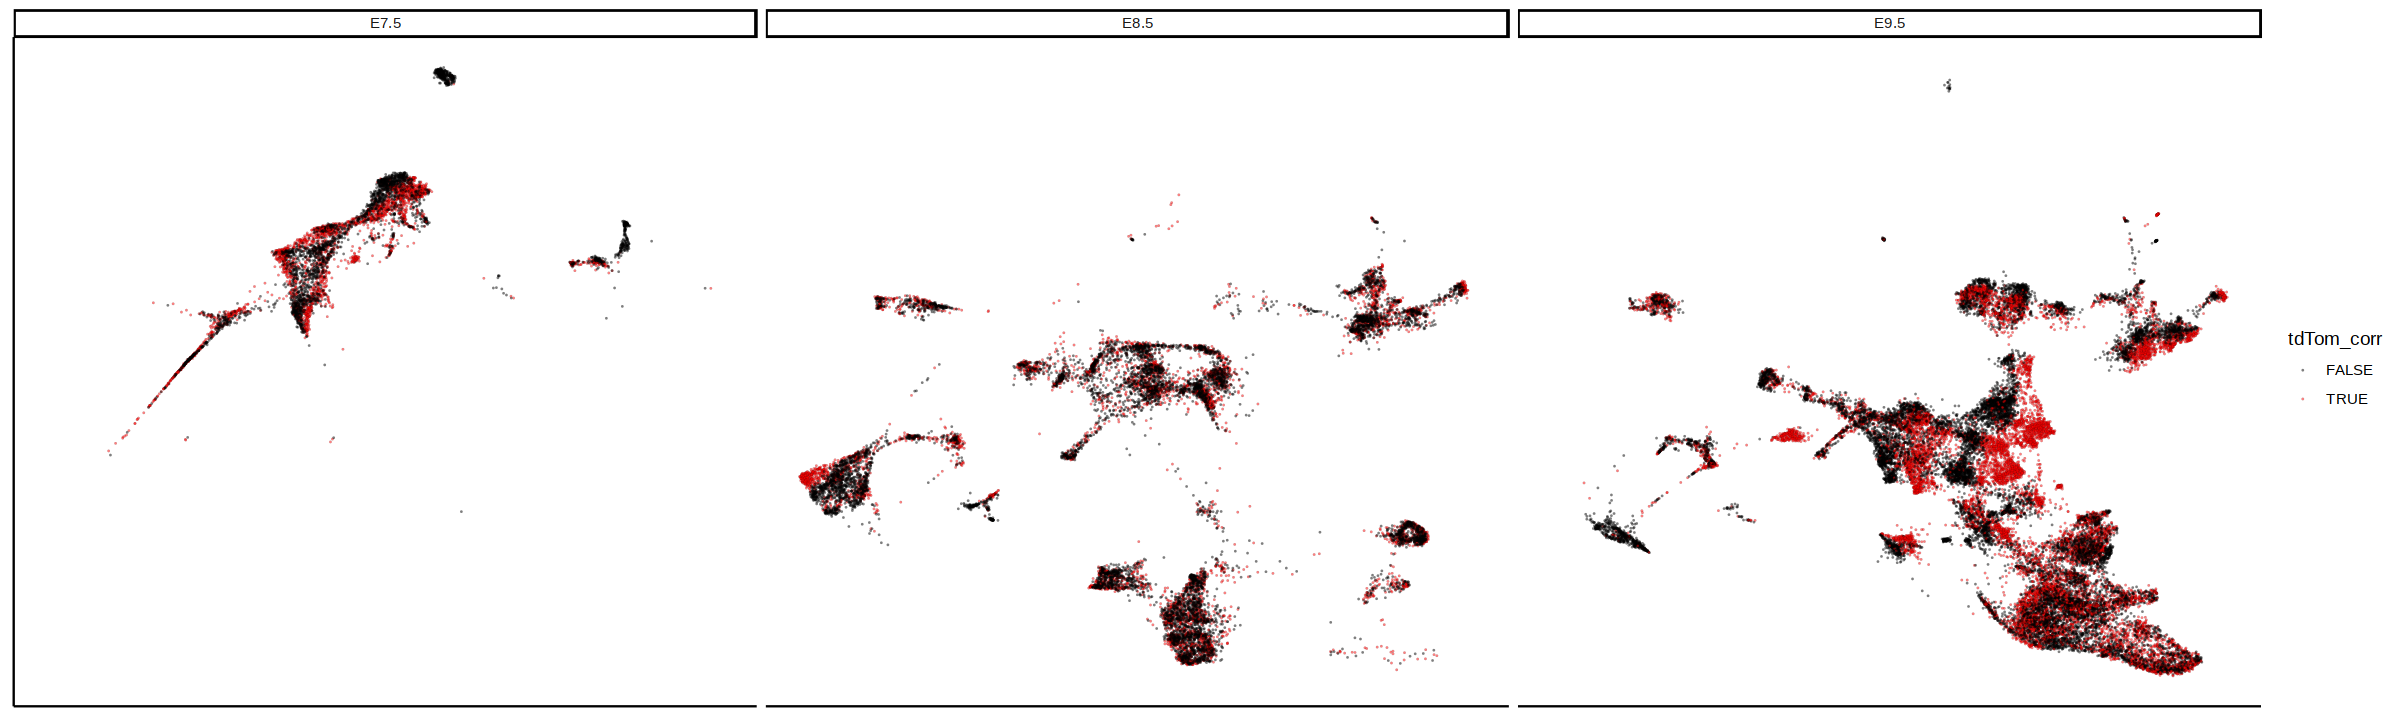

In [14]:
  to.plot <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
    .[,cell:=colnames(sce_filt)] %>%
    merge(sample_metadata, by="cell")

  p <- ggplot(to.plot, aes_string(x="V1", y="V2", fill='tdTom_corr')) +
    geom_point(size=0.4, shape=21, stroke=0.05, alpha=0.5) +
    scale_fill_manual(values=c('TRUE' = 'red', 'FALSE' = 'black')) + 
    facet_wrap(~stage) + 
    theme_classic() +
    theme(
      axis.title = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank()
    )
options(repr.plot.width=20, repr.plot.height=6)
p

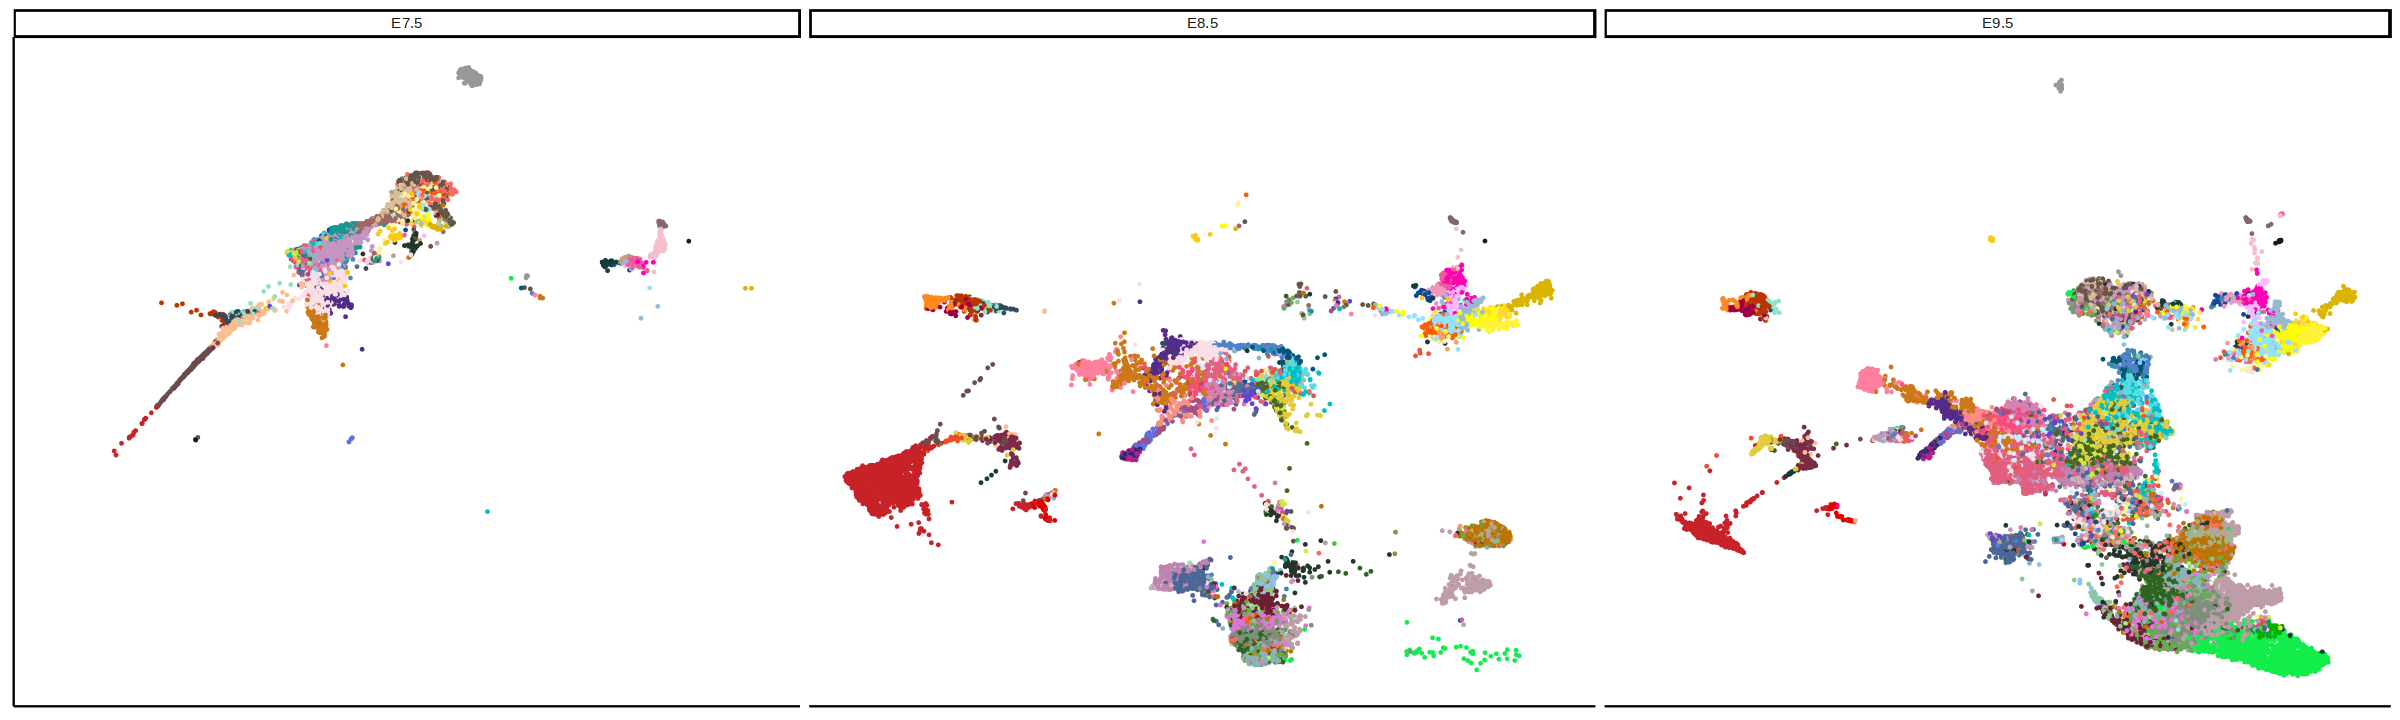

In [15]:
ggplot(to.plot, aes_string(x="V1", y="V2", col='celltype.mapped_mnn')) +
    geom_point(size=0.3) +
    scale_color_manual(values=opts$celltype.colors) + 
    facet_wrap(~stage) + 
    theme_classic() +
    theme(
      axis.title = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank(),
      legend.position='none'
    )

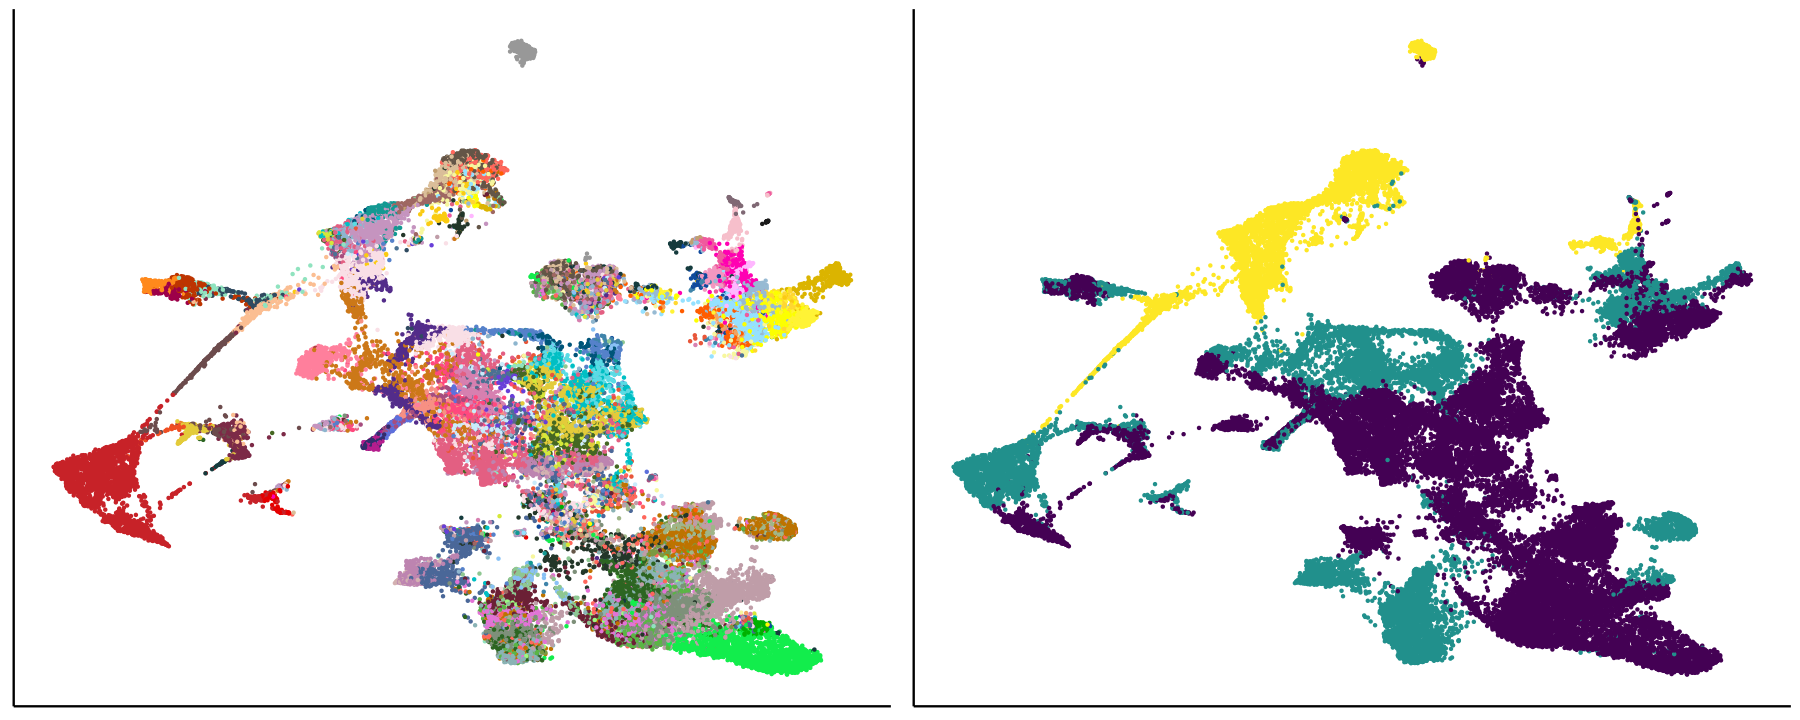

In [16]:
options(repr.plot.width=8, repr.plot.height=6)

p1 = ggplot(to.plot, aes_string(x="V1", y="V2", col='celltype.mapped_mnn')) +
    geom_point(size=0.2) +
    scale_color_manual(values=opts$celltype.colors) + 
    theme_classic() +
    theme(
      axis.title = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank(),
      legend.position='none'
    )

p2 = ggplot(to.plot, aes_string(x="V1", y="V2", col='stage')) +
    geom_point(size=0.2) +
    scale_color_manual(values=opts$stage.colors) + 
    theme_classic() +
    theme(
      axis.title = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank(),
      legend.position='none'
    )

options(repr.plot.width=15, repr.plot.height=6)
ggarrange(p1, p2)

# Regression of variables

In [23]:
colnames(colData(sce_filt))

[1] "sample"                    "barcode"                  
 [3] "nFeature_RNA"              "nCount_RNA"               
 [5] "mitochondrial_percent_RNA" "ribosomal_percent_RNA"    
 [7] "stage"                     "tdTom"                    
 [9] "idx"                       "tdTom_corr"               
[11] "pass_rnaQC"                "doublet_score"            
[13] "doublet_call"              "celltype.mapped_mnn"      
[15] "celltype.score_mnn"        "stage.mapped_mnn"         
[17] "cellstage.score_mnn"       "closest.cell_mnn"

In [19]:
############################
## Regress out covariates ##
############################
args$vars_to_regress = c('nFeature_RNA', 'nCount_RNA', 'mitochondrial_percent_RNA', 'ribosomal_percent_RNA')
 if (length(args$vars_to_regress)>0) {
   print(sprintf("Regressing out variables: %s", paste(args$vars_to_regress,collapse=" ")))
   logcounts(sce_filt) <- RegressOutMatrix(
     mtx = logcounts(sce_filt), 
     covariates = colData(sce_filt)[,args$vars_to_regress,drop=F]
   )
 }


[1] "Regressing out variables: nFeature_RNA nCount_RNA mitochondrial_percent_RNA ribosomal_percent_RNA"


In [25]:
head(sce_filt)

class: SingleCellExperiment 
dim: 6 44673 
metadata(0):
assays(2): counts logcounts
rownames(6): Hbb-bh1 Hbb-y ... Gm42418 mt-Co2
rowData names(0):
colnames(44673): SLX-21143_SITTA2_HTJH3DSX2#AAACCCAAGATGTTCC-1
  SLX-21143_SITTA2_HTJH3DSX2#AAACCCATCAGACCTA-1 ...
  SLX-21143_SITTH3_HTJH3DSX2#TTTGTTGGTAAGATCA-1
  SLX-21143_SITTH3_HTJH3DSX2#TTTGTTGGTCATCGGC-1
colData names(18): sample barcode ... cellstage.score_mnn
  closest.cell_mnn
reducedDimNames(2): PCA UMAP
mainExpName: RNA
altExpNames(0):

In [24]:
head(logcounts(sce_filt))

,SLX-21143_SITTA2_HTJH3DSX2#AAACCCAAGATGTTCC-1,SLX-21143_SITTA2_HTJH3DSX2#AAACCCATCAGACCTA-1,SLX-21143_SITTA2_HTJH3DSX2#AAACGAACAATGTTGC-1,SLX-21143_SITTA2_HTJH3DSX2#AAACGAACACACCAGC-1,SLX-21143_SITTA2_HTJH3DSX2#AAACGAAGTGATAGTA-1,SLX-21143_SITTA2_HTJH3DSX2#AAACGAAGTTAAGACA-1,SLX-21143_SITTA2_HTJH3DSX2#AAACGCTCAGCGTGAA-1,SLX-21143_SITTA2_HTJH3DSX2#AAACGCTCATGGCTGC-1,SLX-21143_SITTA2_HTJH3DSX2#AAACGCTGTATAGCTC-1,SLX-21143_SITTA2_HTJH3DSX2#AAACGCTGTTGCCAAT-1,⋯,SLX-21143_SITTH3_HTJH3DSX2#TTTGGAGCACGAGAAC-1,SLX-21143_SITTH3_HTJH3DSX2#TTTGGTTAGCTGAAGC-1,SLX-21143_SITTH3_HTJH3DSX2#TTTGGTTCAACCGTGC-1,SLX-21143_SITTH3_HTJH3DSX2#TTTGGTTGTCCGGATC-1,SLX-21143_SITTH3_HTJH3DSX2#TTTGGTTGTTAGCTAC-1,SLX-21143_SITTH3_HTJH3DSX2#TTTGTTGAGAGGTTTA-1,SLX-21143_SITTH3_HTJH3DSX2#TTTGTTGAGGCGCTTC-1,SLX-21143_SITTH3_HTJH3DSX2#TTTGTTGCATCTCGTC-1,SLX-21143_SITTH3_HTJH3DSX2#TTTGTTGGTAAGATCA-1,SLX-21143_SITTH3_HTJH3DSX2#TTTGTTGGTCATCGGC-1
Hbb-bh1,6.02490791,1.4073331,1.0876994,6.5279025,5.0421184,0.2057494,-0.1459287,0.6625812,6.0713607,1.2855457,⋯,1.4343471,1.3412546,2.1047503,0.2049087,6.755313,-0.4086994,1.16243081,-1.7476779,1.64842654,-1.492477
Hbb-y,7.43787999,1.6631586,1.3557927,7.5293749,7.2413455,0.7040805,0.4324231,1.2237237,7.3189399,1.6670610,⋯,0.6864340,1.4549321,1.1248679,1.2439226,7.682303,1.5002207,2.34124089,1.2960902,2.27588726,-1.232763
Hba-x,6.93014135,2.2107830,1.6689660,7.7003229,6.8500694,0.6677284,0.6389644,1.5653729,7.2703003,1.6573732,⋯,0.9718480,0.3970579,2.3877426,-1.7320781,6.196350,1.1373038,1.81157318,0.6604941,0.86884801,-1.743540
Hba-a1,5.90877280,0.7638833,0.2406764,6.1307204,5.8061548,0.7154218,0.2957688,1.6364258,5.8977414,0.1993291,⋯,0.9764871,-0.7576851,0.9577022,1.1032215,6.855824,1.4325517,2.07942484,0.9179277,0.81229221,-3.875383
Gm42418,0.04268715,-2.2002884,-0.7035010,-0.4943522,-1.6672756,1.5791765,-0.6068730,-0.2080310,-0.4090188,-0.6485260,⋯,0.5752755,0.9687277,1.3263264,0.8504661,1.459965,0.3722436,0.06349669,0.5890585,0.56725431,1.477170
mt-Co2,2.19810937,0.4385353,-1.6836924,1.2204123,0.9940843,1.1627850,0.5752063,0.5739130,1.1384627,0.8891406,⋯,-0.4230065,0.3677727,0.5096823,0.3582155,1.557130,0.1283656,-0.25960811,1.2325752,-0.02502513,1.471598


In [20]:
sce_filt <- runPCA(sce_filt, ncomponents = args$npcs, ntop=args$features)  

In [21]:
sce_filt <- runUMAP(sce_filt, dimred="PCA", n_neighbors = args$n_neighbors, min_dist = args$min_dist)

# Fetch UMAP coordinates
umap.dt <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
  .[,cell:=colnames(sce_filt)] %>%
  setnames(c("UMAP1","UMAP2","cell"))

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation ideoms with `aes()`”


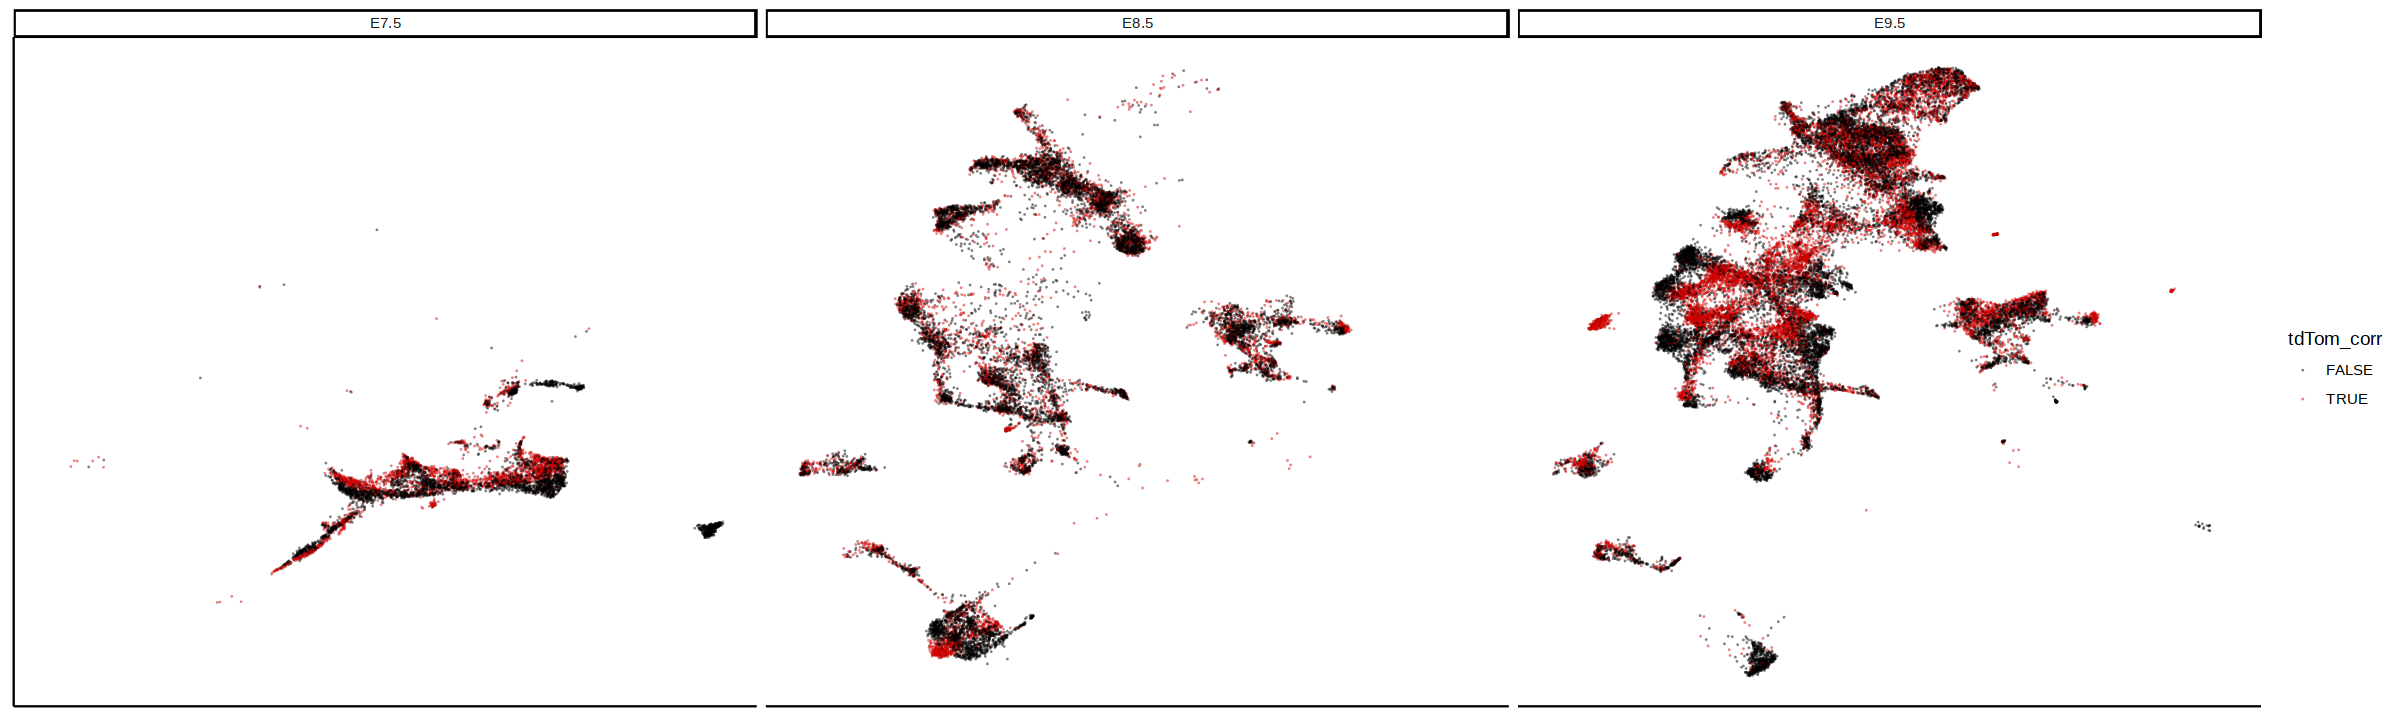

In [22]:
  to.plot <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
    .[,cell:=colnames(sce_filt)] %>%
    merge(sample_metadata, by="cell")

  p <- ggplot(to.plot, aes_string(x="V1", y="V2", fill='tdTom_corr')) +
    geom_point(size=0.4, shape=21, stroke=0.05, alpha=0.5) +
    scale_fill_manual(values=c('TRUE' = 'red', 'FALSE' = 'black')) + 
    facet_wrap(~stage) + 
    theme_classic() +
    theme(
      axis.title = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank()
    )
options(repr.plot.width=20, repr.plot.height=6)
p

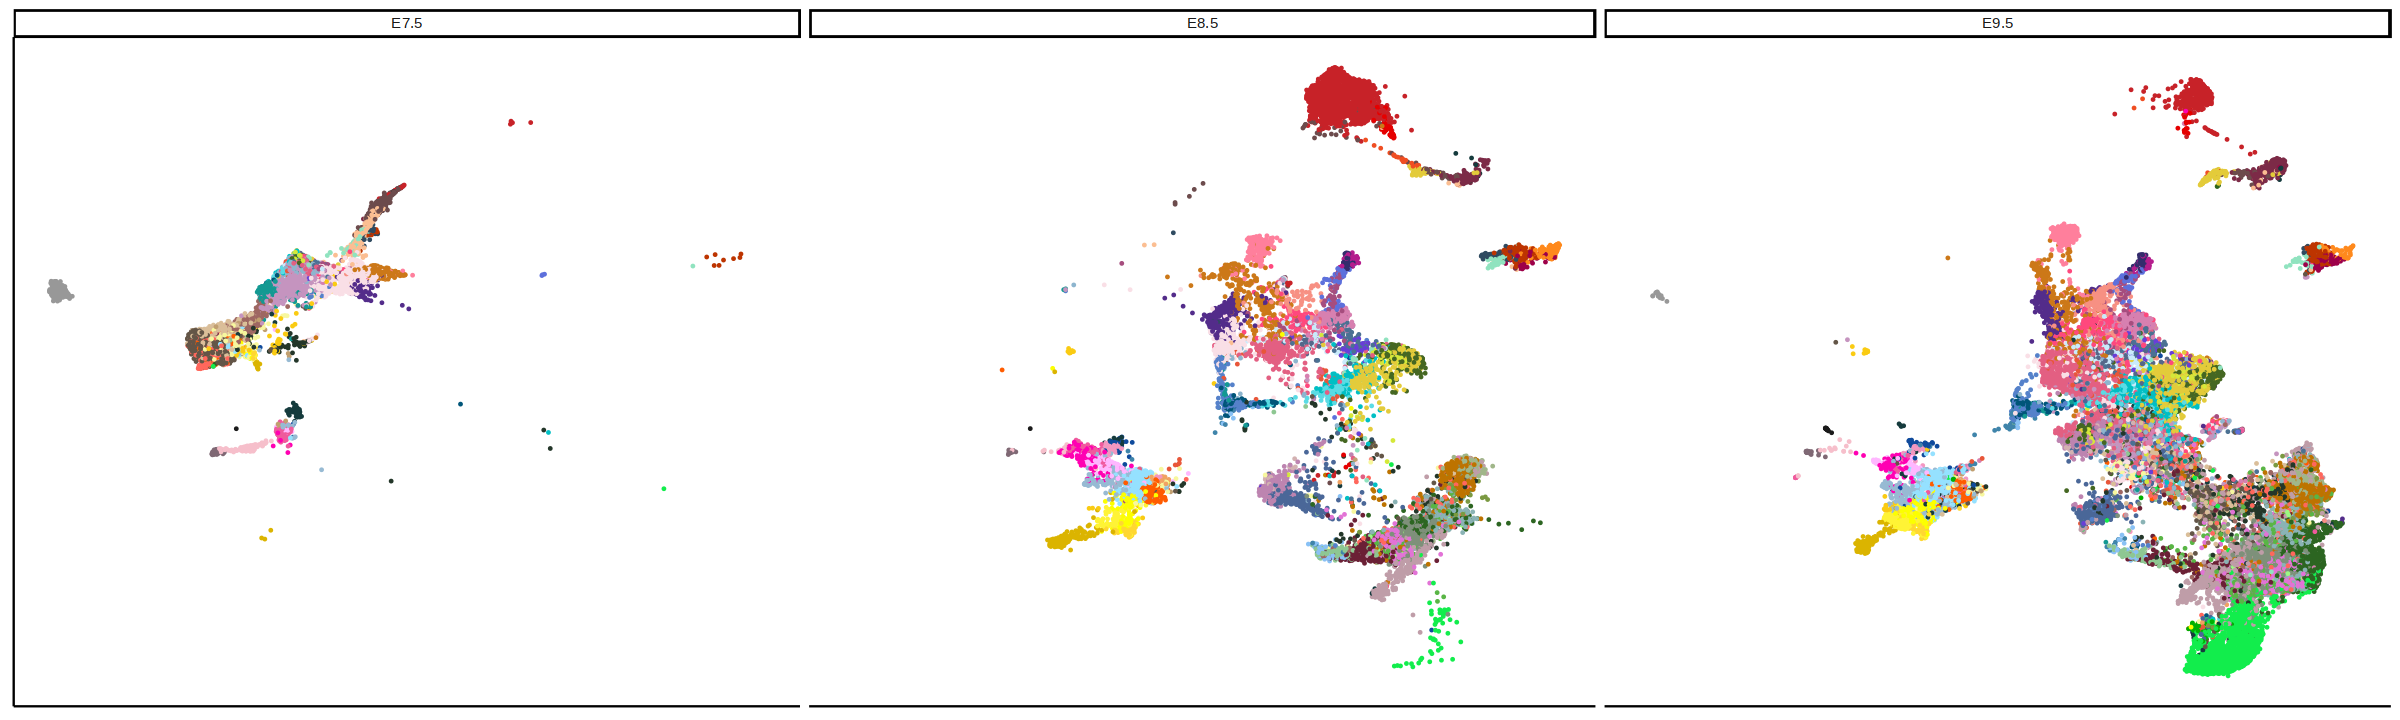

In [22]:
ggplot(to.plot, aes_string(x="V1", y="V2", col='celltype.mapped_mnn')) +
    geom_point(size=0.3) +
    scale_color_manual(values=opts$celltype.colors) + 
    facet_wrap(~stage) + 
    theme_classic() +
    theme(
      axis.title = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank(),
      legend.position='none'
    )

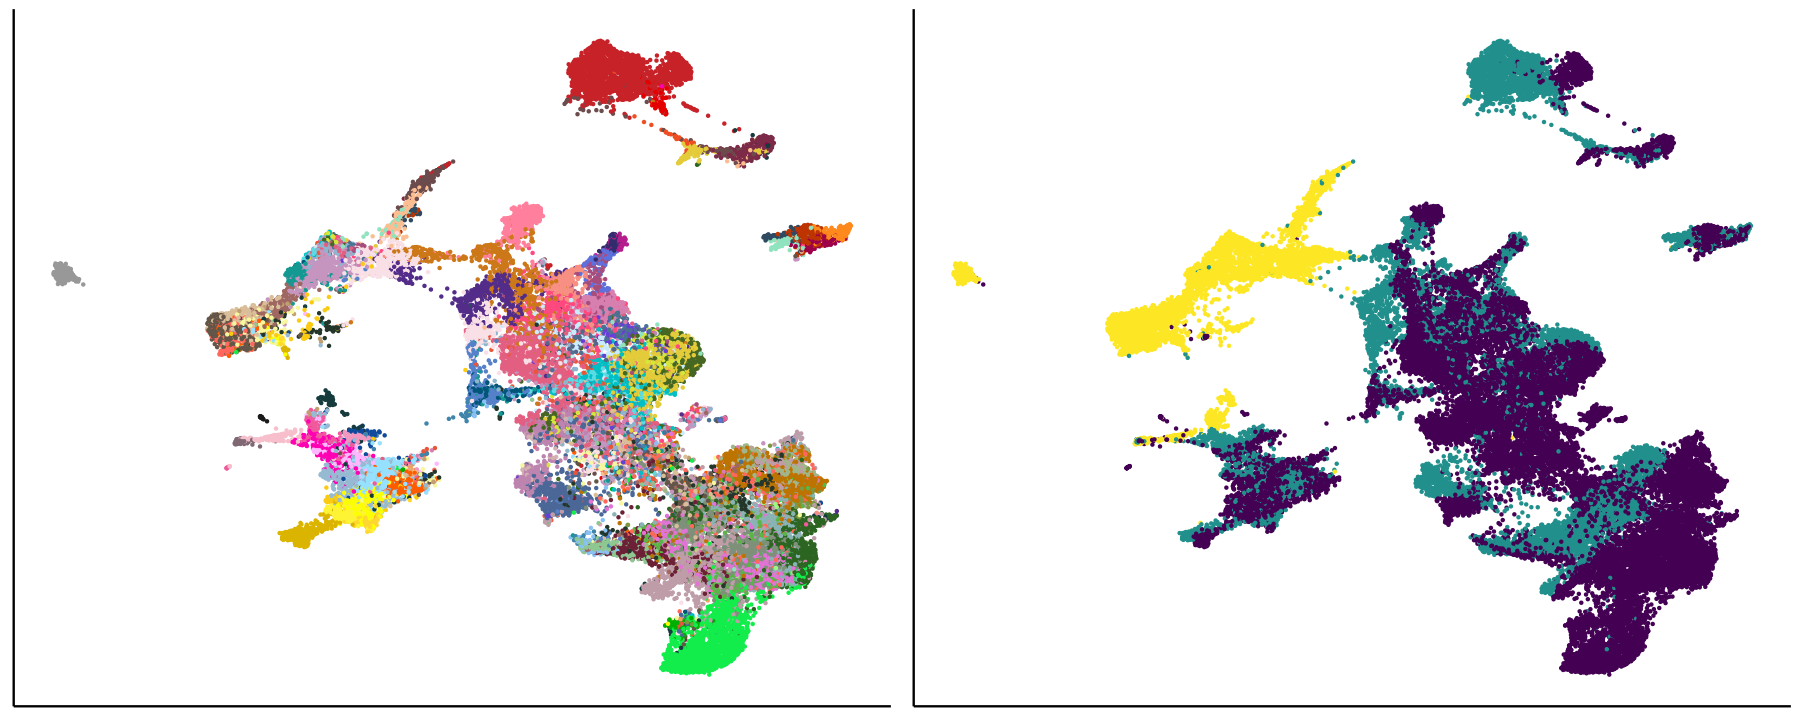

In [23]:
options(repr.plot.width=8, repr.plot.height=6)

p1 = ggplot(to.plot, aes_string(x="V1", y="V2", col='celltype.mapped_mnn')) +
    geom_point(size=0.2) +
    scale_color_manual(values=opts$celltype.colors) + 
    theme_classic() +
    theme(
      axis.title = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank(),
      legend.position='none'
    )

p2 = ggplot(to.plot, aes_string(x="V1", y="V2", col='stage')) +
    geom_point(size=0.2) +
    scale_color_manual(values=opts$stage.colors) + 
    theme_classic() +
    theme(
      axis.title = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank(),
      legend.position='none'
    )

options(repr.plot.width=15, repr.plot.height=6)
ggarrange(p1, p2)

# Batch correction just by stage

In [24]:
# Subset SingleCellExperiment
sce_filt <- sce[hvgs,]

In [25]:
library(batchelor)

In [26]:
args$batch_correction = 'stage'

In [27]:
pca <- multiBatchPCA(sce_filt, batch = colData(sce_filt)[[args$batch_correction]], d = args$npcs)
pca.corrected <- reducedMNN(pca)$corrected
colnames(pca.corrected) <- paste0("PC",1:ncol(pca.corrected))
pca.corrected = pca.corrected[match(colnames(sce_filt), rownames(pca.corrected)),]
summary(colnames(sce_filt) == rownames(pca.corrected))
reducedDim(sce_filt, "PCA") <- pca.corrected

   Mode    TRUE 
logical   45667 

In [28]:
sce_filt

class: SingleCellExperiment 
dim: 3000 45667 
metadata(0):
assays(2): counts logcounts
rownames(3000): Hbb-bh1 Hbb-y ... Omd 9330136K24Rik
rowData names(0):
colnames(45667): SLX-21143_SITTA2_HTJH3DSX2#AAACCCAAGATGTTCC-1
  SLX-21143_SITTA2_HTJH3DSX2#AAACCCATCAGACCTA-1 ...
  SLX-21143_SITTH3_HTJH3DSX2#TTTGTTGGTAAGATCA-1
  SLX-21143_SITTH3_HTJH3DSX2#TTTGTTGGTCATCGGC-1
colData names(18): sample barcode ... idx tdTom_corr
reducedDimNames(1): PCA
mainExpName: RNA
altExpNames(0):

In [29]:
sce_filt <- runUMAP(sce_filt, dimred="PCA", n_neighbors = args$n_neighbors, min_dist = args$min_dist)

# Fetch UMAP coordinates
umap.dt <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
  .[,cell:=colnames(sce_filt)] %>%
  setnames(c("UMAP1","UMAP2","cell"))

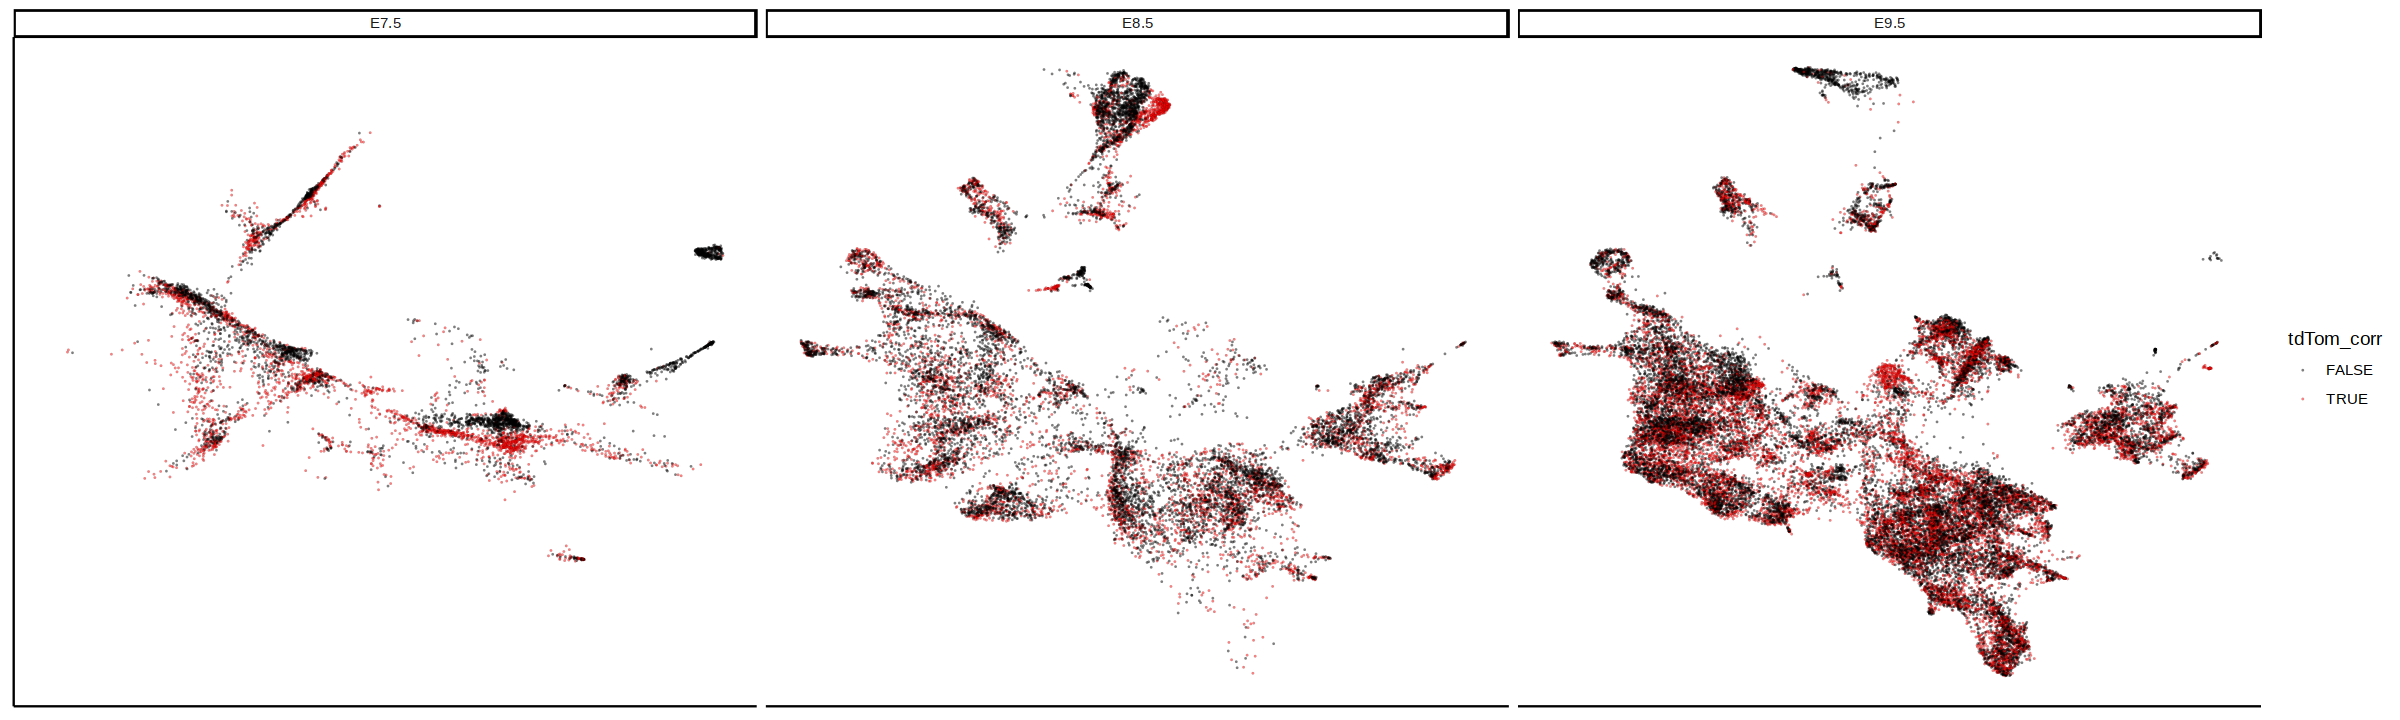

In [30]:
  to.plot <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
    .[,cell:=colnames(sce_filt)] %>%
    merge(sample_metadata, by="cell")

  p <- ggplot(to.plot, aes_string(x="V1", y="V2", fill='tdTom_corr')) +
    geom_point(size=0.4, shape=21, stroke=0.05, alpha=0.5) +
    scale_fill_manual(values=c('TRUE' = 'red', 'FALSE' = 'black')) + 
    facet_wrap(~stage) + 
    theme_classic() +
    theme(
      axis.title = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank()
    )
options(repr.plot.width=20, repr.plot.height=6)
p

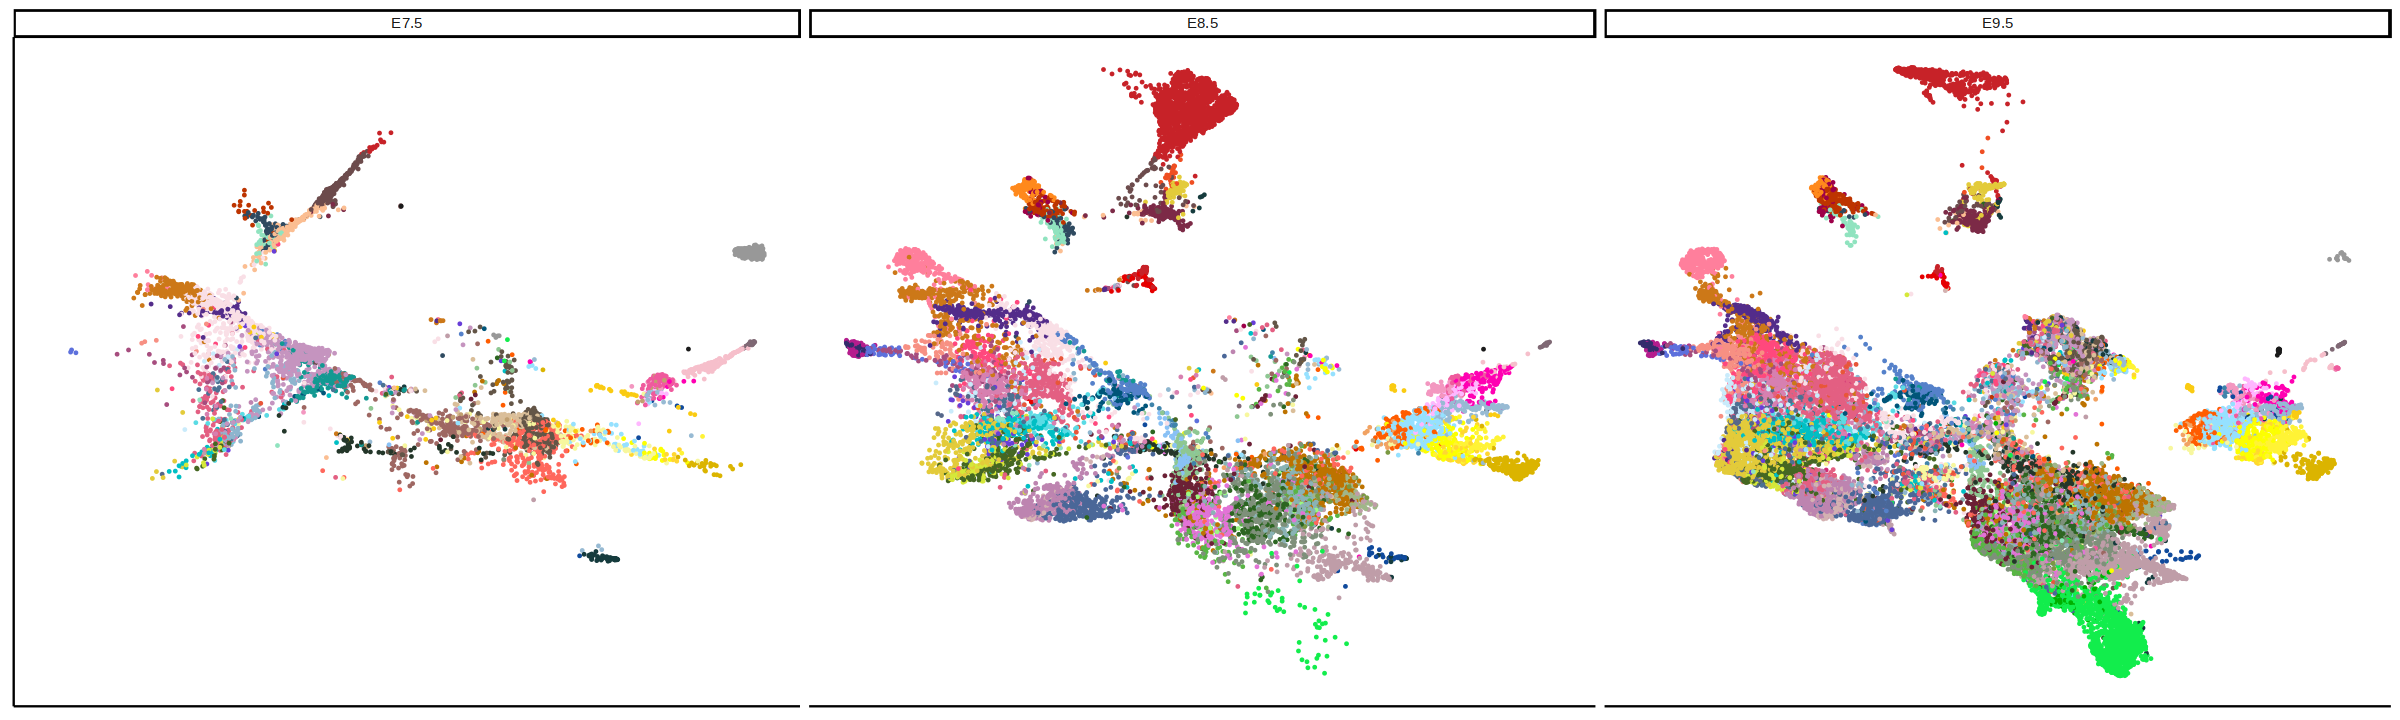

In [31]:
ggplot(to.plot, aes_string(x="V1", y="V2", col='celltype.mapped_mnn')) +
    geom_point(size=0.3) +
    scale_color_manual(values=opts$celltype.colors) + 
    facet_wrap(~stage) + 
    theme_classic() +
    theme(
      axis.title = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank(),
      legend.position='none'
    )

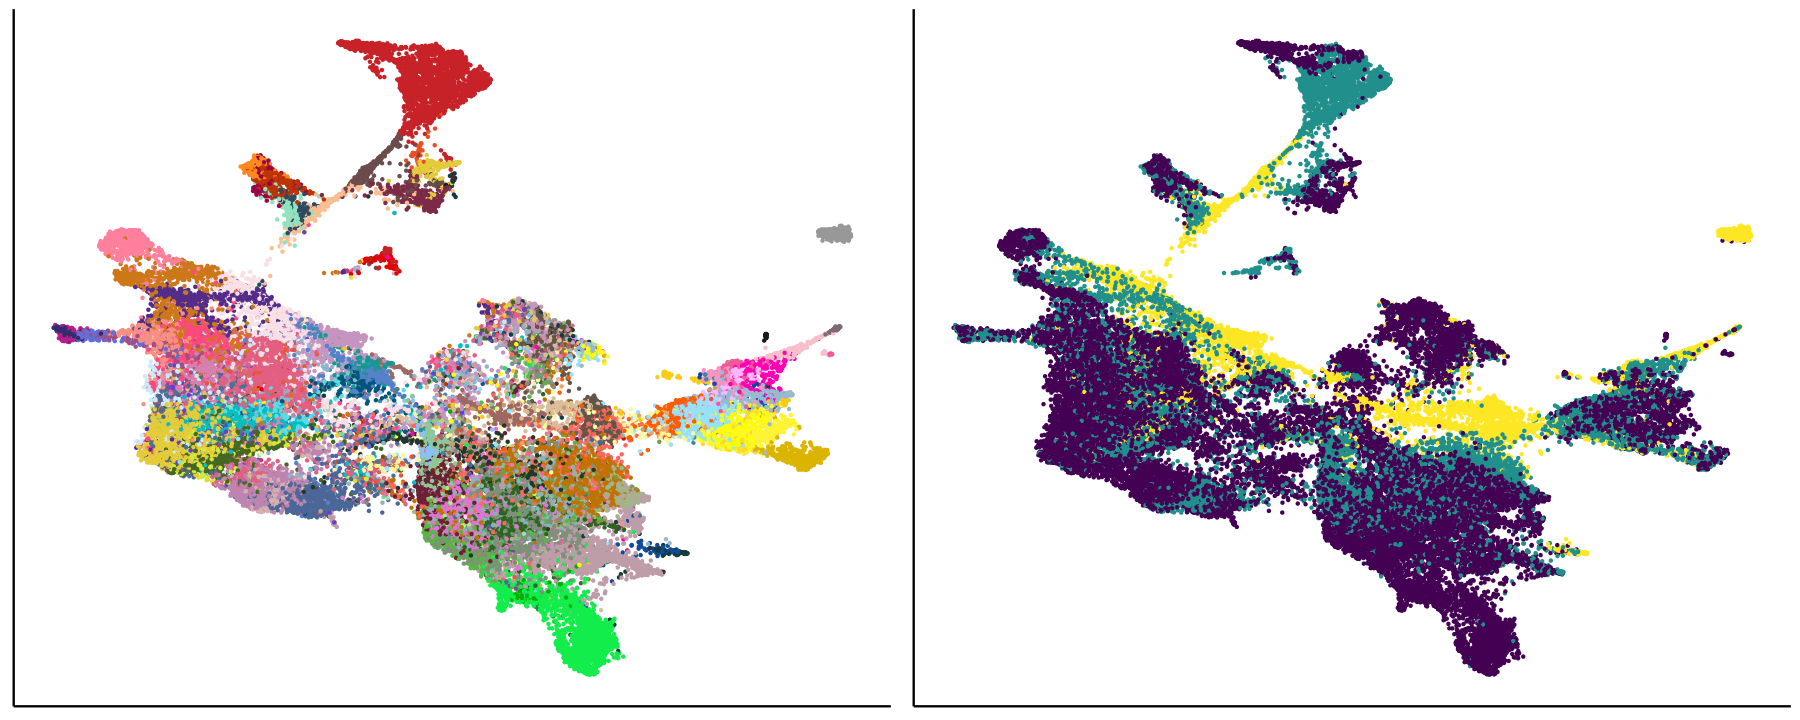

In [32]:
options(repr.plot.width=8, repr.plot.height=6)

p1 = ggplot(to.plot, aes_string(x="V1", y="V2", col='celltype.mapped_mnn')) +
    geom_point(size=0.2) +
    scale_color_manual(values=opts$celltype.colors) + 
    theme_classic() +
    theme(
      axis.title = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank(),
      legend.position='none'
    )

p2 = ggplot(to.plot, aes_string(x="V1", y="V2", col='stage')) +
    geom_point(size=0.2) +
    scale_color_manual(values=opts$stage.colors) + 
    theme_classic() +
    theme(
      axis.title = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank(),
      legend.position='none'
    )

options(repr.plot.width=15, repr.plot.height=6)
ggarrange(p1, p2)

# Regression + stage regression

In [33]:
############################
## Regress out covariates ##
############################
args$vars_to_regress = c('nFeature_RNA', 'nCount_RNA', 'mitochondrial_percent_RNA', 'ribosomal_percent_RNA')
 if (length(args$vars_to_regress)>0) {
   print(sprintf("Regressing out variables: %s", paste(args$vars_to_regress,collapse=" ")))
   logcounts(sce_filt) <- RegressOutMatrix(
     mtx = logcounts(sce_filt), 
     covariates = colData(sce_filt)[,args$vars_to_regress,drop=F]
   )
 }


[1] "Regressing out variables: nFeature_RNA nCount_RNA mitochondrial_percent_RNA ribosomal_percent_RNA"


In [34]:
args$batch_correction = 'stage'

In [35]:
pca <- multiBatchPCA(sce_filt, batch = colData(sce_filt)[[args$batch_correction]], d = args$npcs)
pca.corrected <- reducedMNN(pca)$corrected
colnames(pca.corrected) <- paste0("PC",1:ncol(pca.corrected))
pca.corrected = pca.corrected[match(colnames(sce_filt), rownames(pca.corrected)),]
reducedDim(sce_filt, "PCA") <- pca.corrected

In [36]:
sce_filt <- runUMAP(sce_filt, dimred="PCA", n_neighbors = args$n_neighbors, min_dist = args$min_dist)

# Fetch UMAP coordinates
umap.dt <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
  .[,cell:=colnames(sce_filt)] %>%
  setnames(c("UMAP1","UMAP2","cell"))

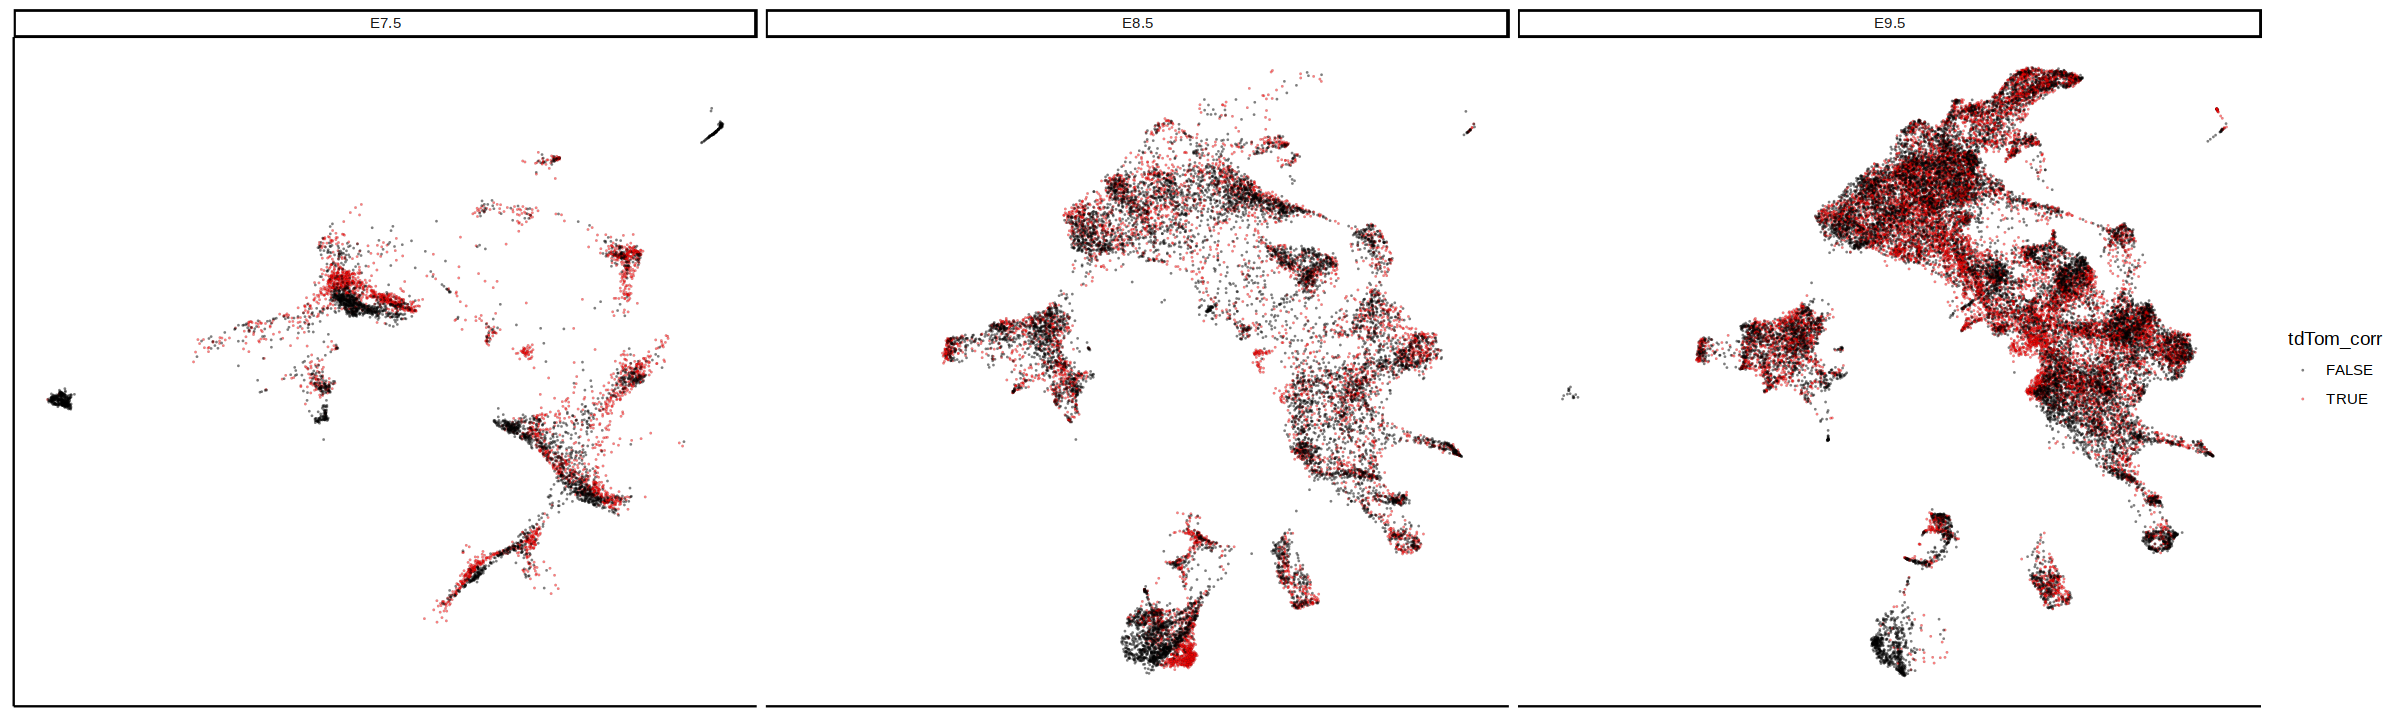

In [37]:
  to.plot <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
    .[,cell:=colnames(sce_filt)] %>%
    merge(sample_metadata, by="cell")

  p <- ggplot(to.plot, aes_string(x="V1", y="V2", fill='tdTom_corr')) +
    geom_point(size=0.4, shape=21, stroke=0.05, alpha=0.5) +
    scale_fill_manual(values=c('TRUE' = 'red', 'FALSE' = 'black')) + 
    facet_wrap(~stage) + 
    theme_classic() +
    theme(
      axis.title = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank()
    )
options(repr.plot.width=20, repr.plot.height=6)
p

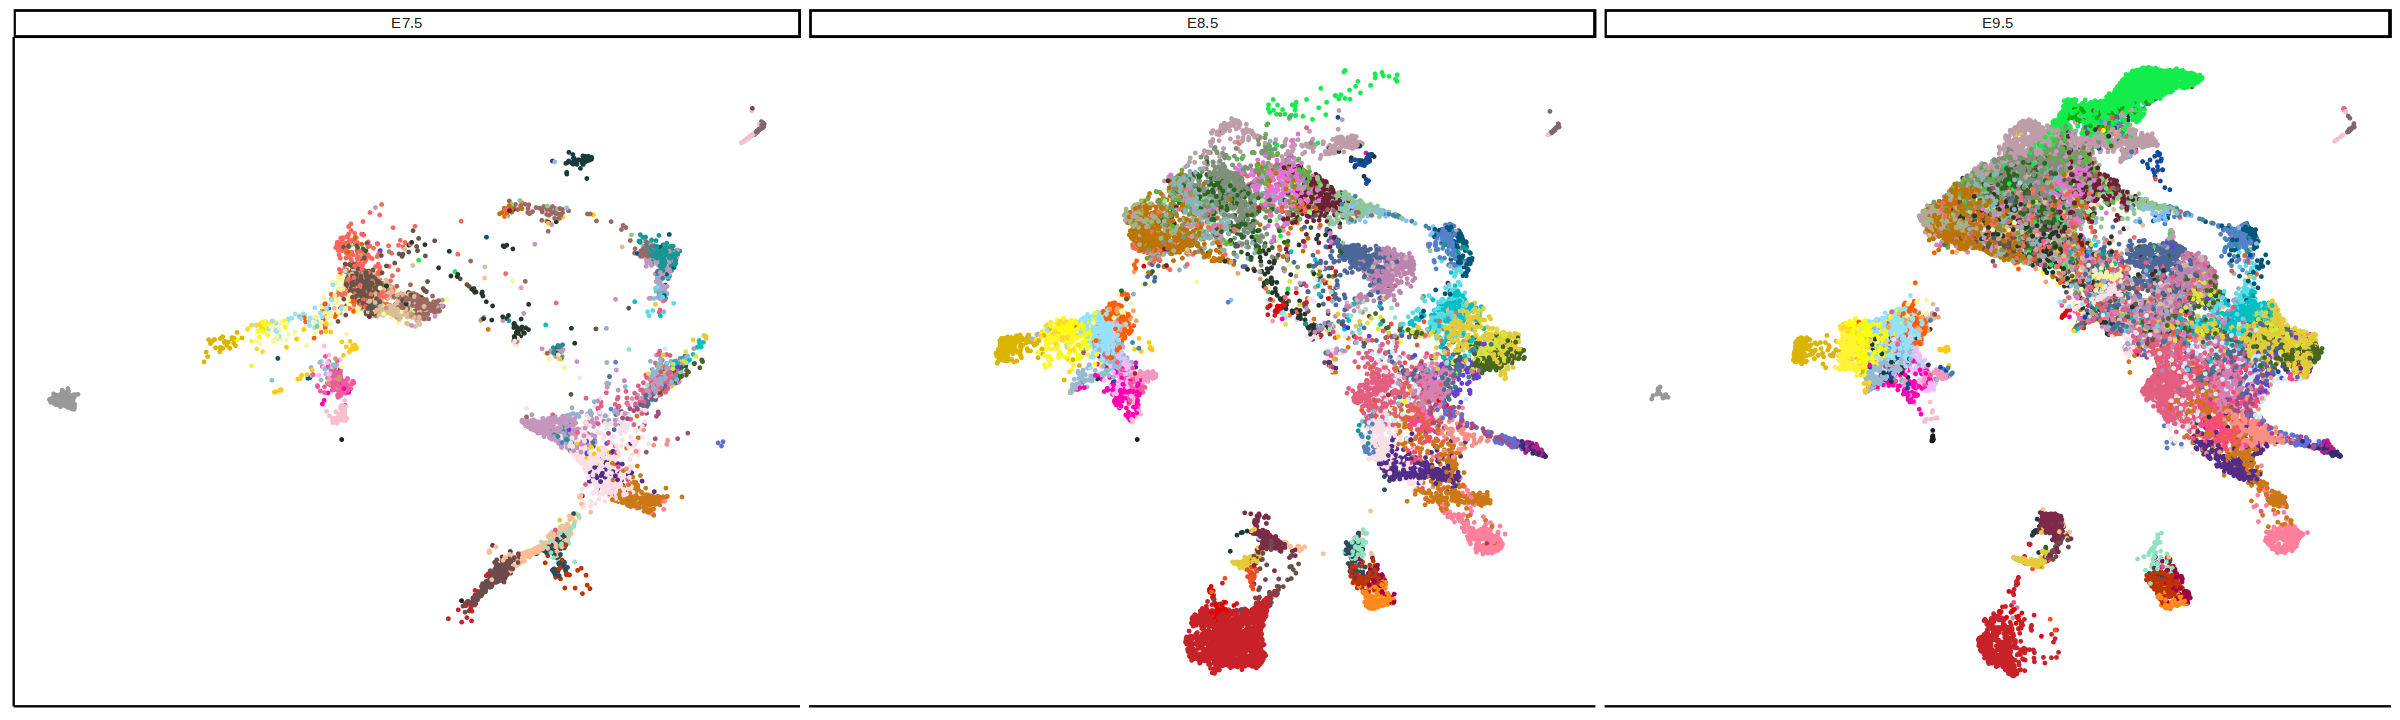

In [38]:
ggplot(to.plot, aes_string(x="V1", y="V2", col='celltype.mapped_mnn')) +
    geom_point(size=0.3) +
    scale_color_manual(values=opts$celltype.colors) + 
    facet_wrap(~stage) + 
    theme_classic() +
    theme(
      axis.title = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank(),
      legend.position='none'
    )

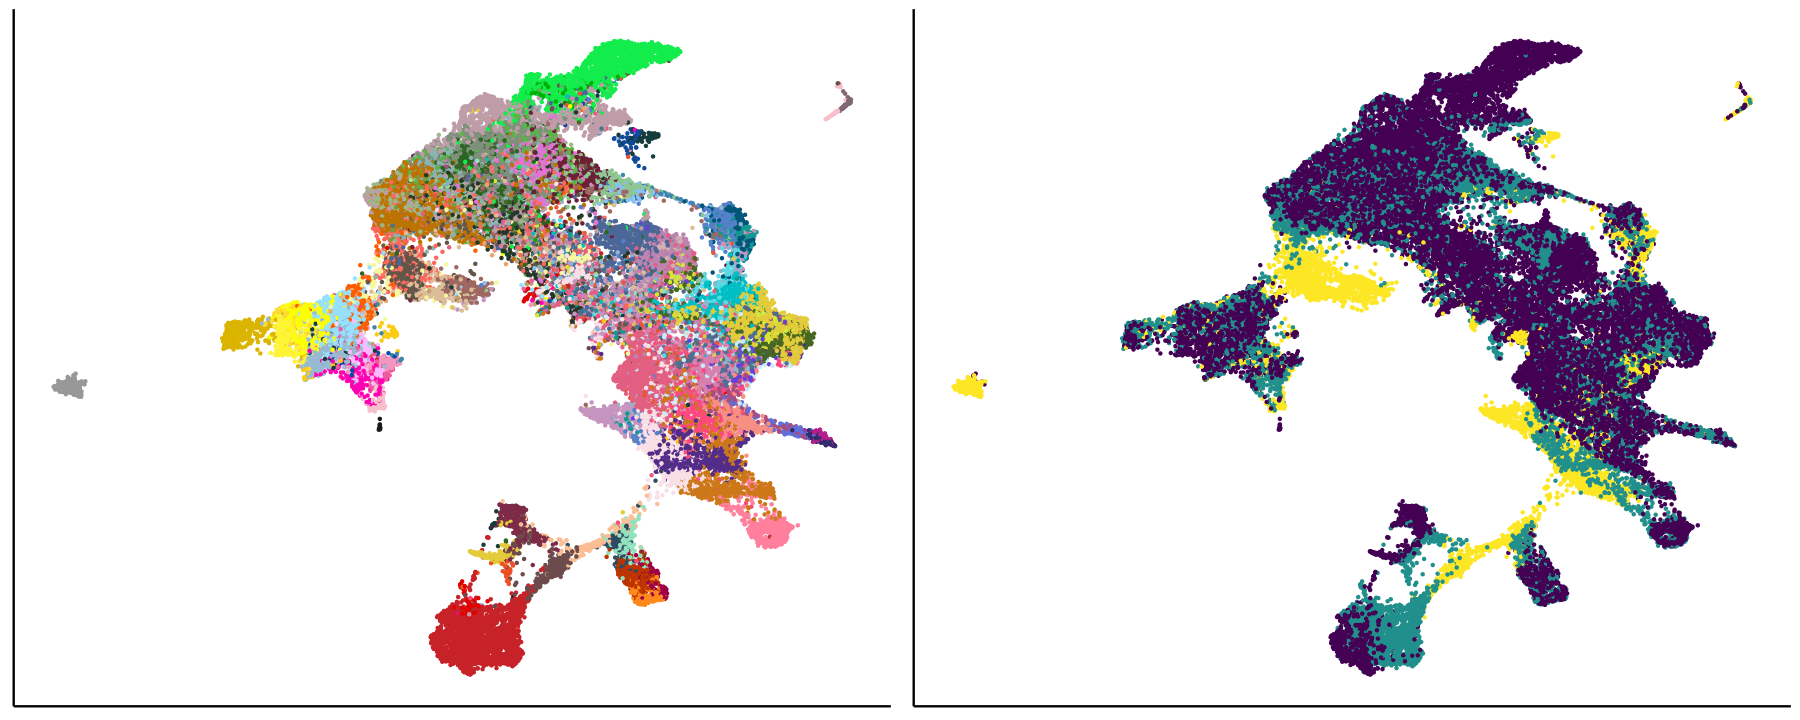

In [39]:
options(repr.plot.width=8, repr.plot.height=6)

p1 = ggplot(to.plot, aes_string(x="V1", y="V2", col='celltype.mapped_mnn')) +
    geom_point(size=0.2) +
    scale_color_manual(values=opts$celltype.colors) + 
    theme_classic() +
    theme(
      axis.title = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank(),
      legend.position='none'
    )

p2 = ggplot(to.plot, aes_string(x="V1", y="V2", col='stage')) +
    geom_point(size=0.2) +
    scale_color_manual(values=opts$stage.colors) + 
    theme_classic() +
    theme(
      axis.title = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank(),
      legend.position='none'
    )

options(repr.plot.width=15, repr.plot.height=6)
ggarrange(p1, p2)

In [41]:
colnames(to.plot)

[1] "cell"                      "V1"                       
 [3] "V2"                        "sample"                   
 [5] "barcode"                   "nFeature_RNA"             
 [7] "nCount_RNA"                "mitochondrial_percent_RNA"
 [9] "ribosomal_percent_RNA"     "stage"                    
[11] "tdTom"                     "pass_rnaQC"               
[13] "doublet_score"             "doublet_call"             
[15] "celltype.mapped_mnn"       "celltype.score_mnn"       
[17] "stage.mapped_mnn"          "cellstage.score_mnn"      
[19] "closest.cell_mnn"          "idx"                      
[21] "tdTom_corr"

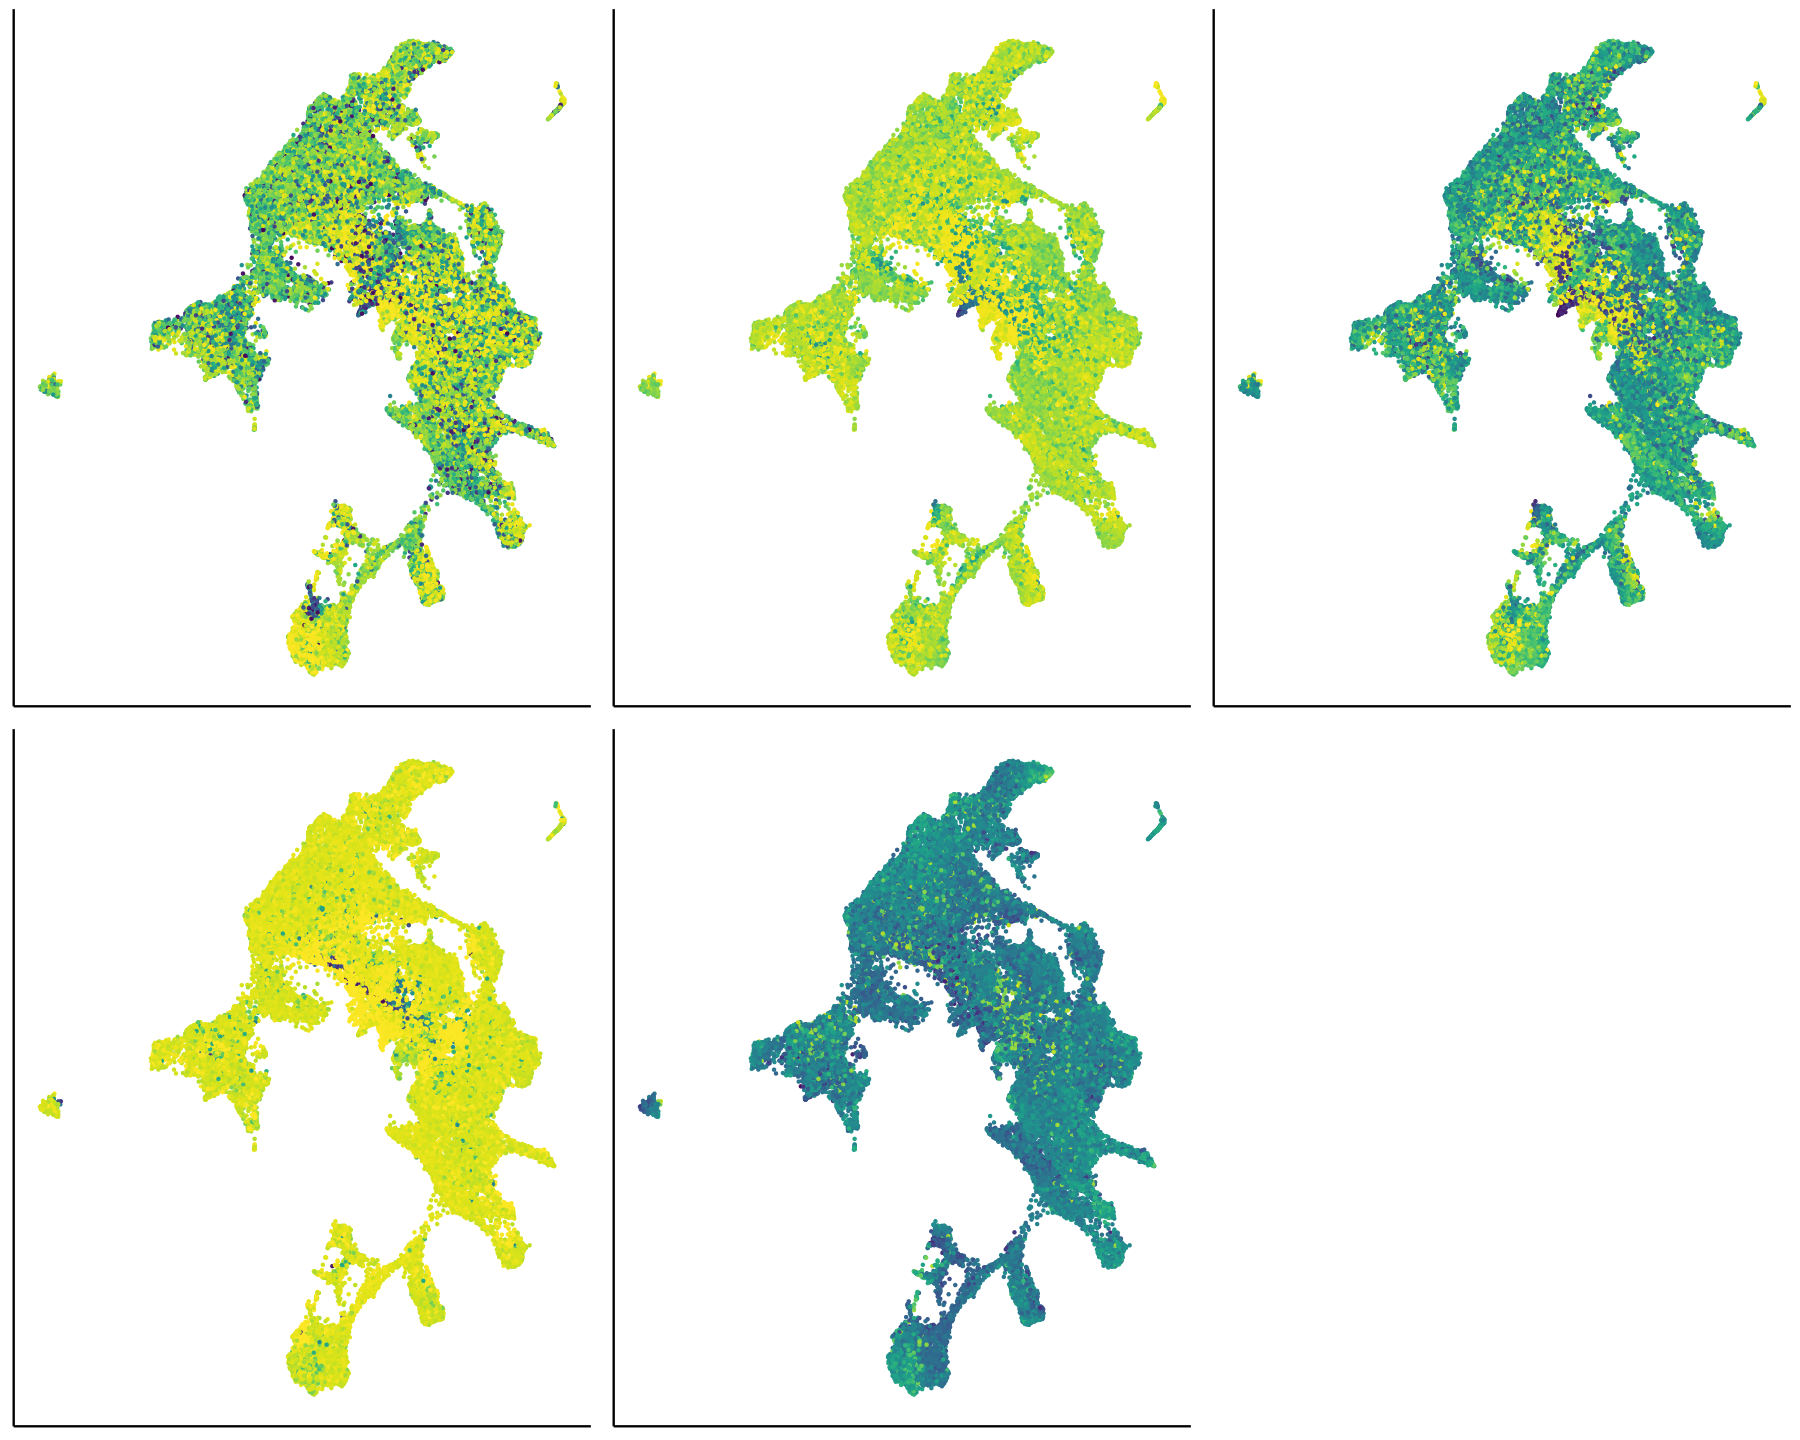

In [43]:
p1 = ggplot(to.plot, aes_string(x="V1", y="V2", col='doublet_score')) +
    geom_point(size=0.2) +
    viridis::scale_color_viridis(begin=1, end=0) + 
    theme_classic() +
    theme(
      axis.title = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank(),
      legend.position='none'
    )

p2 = ggplot(to.plot, aes_string(x="V1", y="V2", col='nCount_RNA')) +
    geom_point(size=0.2) +
    viridis::scale_color_viridis(begin=1, end=0) + 
    theme_classic() +
    theme(
      axis.title = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank(),
      legend.position='none'
    )

p3 = ggplot(to.plot, aes_string(x="V1", y="V2", col='nFeature_RNA')) +
    geom_point(size=0.2) +
    viridis::scale_color_viridis(begin=1, end=0) + 
    theme_classic() +
    theme(
      axis.title = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank(),
      legend.position='none'
    )

p4 = ggplot(to.plot, aes_string(x="V1", y="V2", col='mitochondrial_percent_RNA')) +
    geom_point(size=0.2) +
    viridis::scale_color_viridis(begin=1, end=0) + 
    theme_classic() +
    theme(
      axis.title = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank(),
      legend.position='none'
    )

p5 = ggplot(to.plot, aes_string(x="V1", y="V2", col='ribosomal_percent_RNA')) +
    geom_point(size=0.2) +
    viridis::scale_color_viridis(begin=1, end=0) + 
    theme_classic() +
    theme(
      axis.title = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank(),
      legend.position='none'
    )

options(repr.plot.width=15, repr.plot.height=12)
ggarrange(p1, p2, p3, p4, p5)

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”


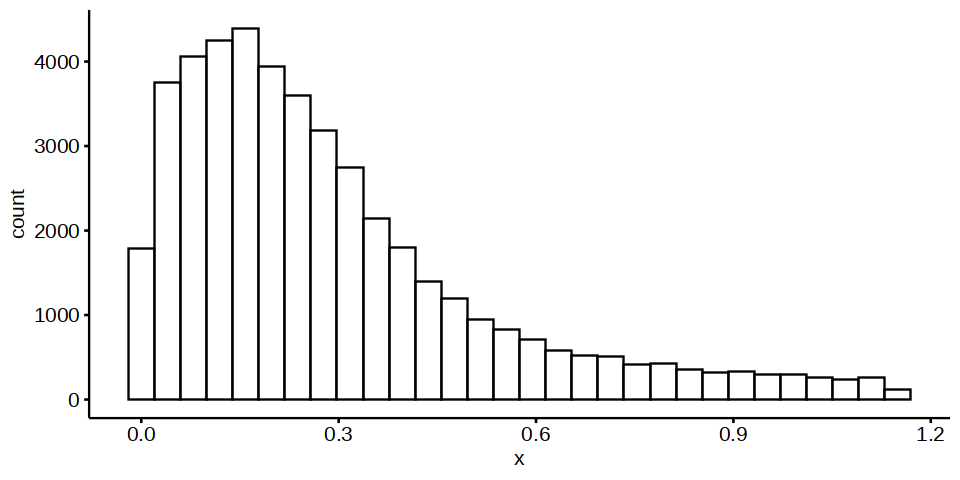

In [44]:
options(repr.plot.width=8, repr.plot.height=4)
gghistogram(to.plot$doublet_score)

In [46]:
library(miloR)

ERROR: Error in library(miloR): there is no package called ‘miloR’
